In [1]:
from __future__ import print_function, division   
import pandas as pd 
from pandas import Series, DataFrame 
from matplotlib import pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from sklearn.metrics import mean_absolute_error, r2_score, roc_auc_score

import optuna
import umap
from sklearn.metrics import silhouette_score

import lightgbm as lgb 
from scipy.stats import randint, poisson
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA, KernelPCA

from sklearn.metrics import mean_squared_error, log_loss
from lightgbm import early_stopping
import time

SavePlots = False

import sys
sys.path.insert(1, '/Users/fbnielsen/Library/CloudStorage/OneDrive-UniversityofCopenhagen/Uni OneDrive/4 år/AMAS')

import amasF as F

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re

from iminuit.cost import UnbinnedNLL
from iminuit import Minuit, cost

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 16,
    "axes.grid": True,
    "grid.alpha": 0.2
})

import re

def contains_element(formula, element):
    # Match element symbol not followed by a lowercase letter (avoids e.g. 'Co' matching 'C')
    pattern = r'(?<![A-Z])' + element + r'(?![a-z])'
    return bool(re.search(pattern, str(formula)))

/Users/fbnielsen/miniconda3/envs/tf/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
sc_features

,Unnamed: 0,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,MagpieData avg_dev Number,MagpieData mode Number,MagpieData minimum MendeleevNumber,MagpieData maximum MendeleevNumber,MagpieData range MendeleevNumber,...,Tl,Tm,U,V,W,Y,Yb,Zn,Zr,source
0,0,8.0,33.0,25.0,15.875000,6.734375,8.0,7.0,87.0,80.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,1,5.0,39.0,34.0,18.333333,13.000000,5.0,12.0,77.0,65.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1
2,2,20.0,58.0,38.0,29.805000,5.873525,33.0,7.0,84.0,77.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,3,8.0,81.0,73.0,22.518634,15.901682,8.0,7.0,87.0,80.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,4,5.0,41.0,36.0,16.136691,15.383055,5.0,47.0,72.0,25.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13656,13656,8.0,80.0,72.0,23.024062,15.989303,8.0,7.0,87.0,80.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
13657,13657,8.0,82.0,74.0,23.561425,16.924766,8.0,7.0,87.0,80.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
13658,13658,1.0,16.0,15.0,4.750000,5.625000,1.0,88.0,92.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
13659,13659,1.0,16.0,15.0,6.000000,6.666667,1.0,88.0,92.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


=== Loading Data ===

SuperCon:           13661 materials, 231 features
Materials Project: 153209 materials, 233 features

=== Removing MP materials that overlap with SuperCon ===

Overlapping materials removed: 117
MP materials remaining:        153092

=== Aligning features and creating labels ===

Features in SuperCon only:  2
Features in MP only:        4
Shared features used:       228

Combined dataset shape: (166753, 229)
Class balance — SC (1): 8.2%  |  MP (0): 91.8%

=== Data Quality ===

✅ No missing values: True

=== Removing highly correlated features (threshold=0.90) ===

Dropped 37 correlated features. Remaining: 191

=== Stratified 3-Way Split (75 / 15 / 10) ===

Train: 125064 rows  |  Val: 25013 rows  |  Test: 16676 rows
SC fraction — Train: 8.2%  Val: 8.2%  Test: 8.2%

=== Feature Selection ===

Class imbalance ratio (scale_pos_weight): 11.21
Top 20 tree importance features selected.
Top 20 SHAP features selected.

Final feature set (union of top-20 tree + top-20 SHAP)

/Users/fbnielsen/miniconda3/envs/tf/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Best hyperparameters:
  subsample: 0.8
  n_estimators: 1000
  min_child_weight: 5
  max_depth: 12
  learning_rate: 0.02
  gamma: 0.05
  colsample_bytree: 0.3

Baseline — LogLoss: 0.0991  ROC-AUC: 0.9899
Tuned    — LogLoss: 0.0723  ROC-AUC: 0.9921

=== Final Test Set Evaluation ===

Test LogLoss:  0.0709
Test ROC-AUC:  0.9929
Test Accuracy: 97.30%

                     precision    recall  f1-score   support

        Non-SC (MP)       0.99      0.98      0.99     15310
Superconductor (SC)       0.79      0.91      0.85      1366

           accuracy                           0.97     16676
          macro avg       0.89      0.94      0.92     16676
       weighted avg       0.98      0.97      0.97     16676



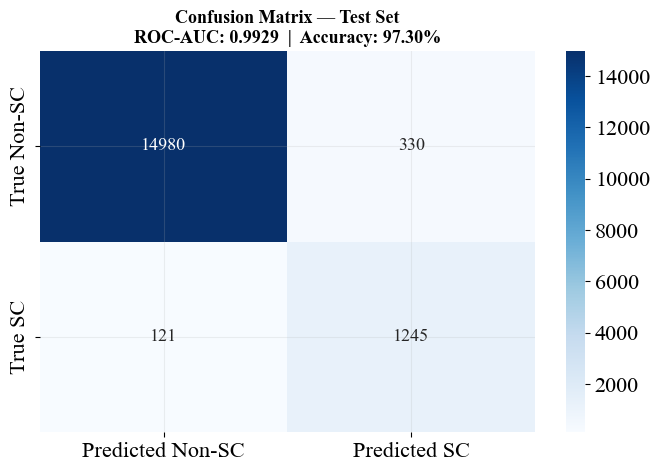


=== SHAP Summary Plot (Final Model) ===



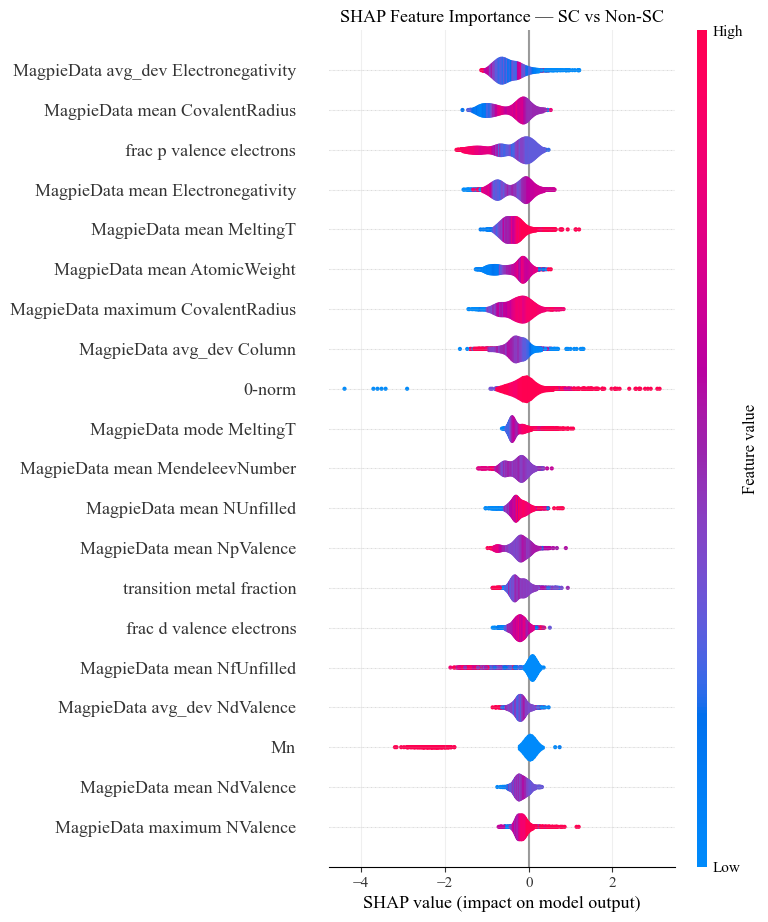

Saved: classification_confusion_matrix.png, classification_shap_summary.png


In [4]:
import pandas as pd
import numpy as np
import shap
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import log_loss, roc_auc_score, accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

# ── 1. Load data ───────────────────────────────────────────────────────────────
print("=== Loading Data ===\n")

# SuperCon features (superconductors, source=1)
sc_features = pd.read_csv('SuperCon_chem_df.csv')
chem_SC     = np.load('/Users/fbnielsen/Desktop/AML/Final project/Supplementary_1/SuperCon_chemical_compositions.npy', allow_pickle=True)

# Materials Project features (non-superconductors, source=0)
mp_features = pd.read_csv('MP_chem_df.csv')
chem_MP     = np.load('/Users/fbnielsen/Desktop/AML/Final project/Supplementary_1/Materials_Project_chemical_compositions.npy')  

sc_features=sc_features.drop('Unnamed: 0', axis=1)
mp_features=mp_features.drop('Unnamed: 0', axis=1)

print(f"SuperCon:          {sc_features.shape[0]:>6} materials, {sc_features.shape[1]} features")
print(f"Materials Project: {mp_features.shape[0]:>6} materials, {mp_features.shape[1]} features")

# ── 2. Remove MP materials that also appear in SuperCon ───────────────────────
print("\n=== Removing MP materials that overlap with SuperCon ===\n")

sc_set   = set(chem_SC)
overlap  = np.array([f in sc_set for f in chem_MP])
mp_clean = mp_features[~overlap].copy()

print(f"Overlapping materials removed: {overlap.sum()}")
print(f"MP materials remaining:        {mp_clean.shape[0]}")

# ── 3. Add source labels and align columns ────────────────────────────────────
print("\n=== Aligning features and creating labels ===\n")

sc_features = sc_features.copy()
sc_features['source'] = 1   # superconductor

mp_clean = mp_clean.copy()
mp_clean['source'] = 0      # non-superconductor

# Keep only shared feature columns (excluding source)
sc_cols = set(sc_features.columns) - {'source'}
mp_cols = set(mp_clean.columns)    - {'source'}
shared_cols = sorted(sc_cols & mp_cols)

print(f"Features in SuperCon only:  {len(sc_cols - mp_cols)}")
print(f"Features in MP only:        {len(mp_cols - sc_cols)}")
print(f"Shared features used:       {len(shared_cols)}")

df = pd.concat([
    sc_features[shared_cols + ['source']],
    mp_clean[shared_cols    + ['source']],
], axis=0, ignore_index=True)

print(f"\nCombined dataset shape: {df.shape}")
print(f"Class balance — SC (1): {df['source'].mean()*100:.1f}%  |  MP (0): {(1-df['source'].mean())*100:.1f}%")

# ── 4. Data quality checks ────────────────────────────────────────────────────
print("\n=== Data Quality ===\n")

# Remove zero-variance columns
zero_var = [c for c in shared_cols if df[c].nunique() <= 1]
if zero_var:
    print(f"Dropping {len(zero_var)} zero-variance columns")
    df = df.drop(columns=zero_var)
    shared_cols = [c for c in shared_cols if c not in zero_var]

# Fill any NaNs with column median
nan_count = df[shared_cols].isna().sum().sum()
if nan_count:
    print(f"Filling {nan_count} NaN values with column median")
    df[shared_cols] = df[shared_cols].fillna(df[shared_cols].median())

print(f"✅ No missing values: {df.isna().sum().sum() == 0}")

# ── 5. Remove highly correlated features (>0.90) ─────────────────────────────
print("\n=== Removing highly correlated features (threshold=0.90) ===\n")

corr_matrix   = df[shared_cols].corr(method='pearson').abs()
upper         = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop       = [c for c in upper.columns if any(upper[c] > 0.90)]
shared_cols   = [c for c in shared_cols if c not in to_drop]
df            = df[shared_cols + ['source']]

print(f"Dropped {len(to_drop)} correlated features. Remaining: {len(shared_cols)}")

# ── 6. Train / Validation / Test split (75 / 15 / 10) ────────────────────────
print("\n=== Stratified 3-Way Split (75 / 15 / 10) ===\n")

target_col = 'source'

temp_df, test_df = train_test_split(
    df, test_size=0.10, random_state=42, stratify=df[target_col]
)
train_df, val_df = train_test_split(
    temp_df, test_size=(0.15 / 0.90), random_state=42, stratify=temp_df[target_col]
)

X_train = train_df[shared_cols];  y_train = train_df[target_col]
X_val   = val_df[shared_cols];    y_val   = val_df[target_col]
X_test  = test_df[shared_cols];   y_test  = test_df[target_col]

print(f"Train: {X_train.shape[0]} rows  |  Val: {X_val.shape[0]} rows  |  Test: {X_test.shape[0]} rows")
print(f"SC fraction — Train: {y_train.mean()*100:.1f}%  Val: {y_val.mean()*100:.1f}%  Test: {y_test.mean()*100:.1f}%")

# ── 7. Feature selection via SHAP + Permutation + Tree importance ─────────────
print("\n=== Feature Selection ===\n")

neg_count       = (y_train == 0).sum()
pos_count       = (y_train == 1).sum()
imbalance_ratio = neg_count / pos_count
print(f"Class imbalance ratio (scale_pos_weight): {imbalance_ratio:.2f}")

# --- Tree importance (XGBoost) ---
xgb_fs = xgb.XGBClassifier(
    scale_pos_weight=imbalance_ratio,
    n_estimators=300, max_depth=6, learning_rate=0.1,
    random_state=42, eval_metric='logloss', n_jobs=-1
)
xgb_fs.fit(X_train, y_train)
tree_imp = pd.Series(xgb_fs.feature_importances_, index=shared_cols).sort_values(ascending=False)
top_20_tree = tree_imp.head(20).index.tolist()
print(f"Top 20 tree importance features selected.")

# --- SHAP (Random Forest on sample) ---
rf_fs = RandomForestClassifier(
    n_estimators=100, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1
)
rf_fs.fit(X_train, y_train)
X_shap_sample = X_train.sample(n=min(2500, len(X_train)), random_state=42)
explainer     = shap.TreeExplainer(rf_fs)
shap_vals     = explainer.shap_values(X_shap_sample)

# Handle both old and new SHAP output formats
if isinstance(shap_vals, list):
    sv = shap_vals[1]
elif len(shap_vals.shape) == 3:
    sv = shap_vals[:, :, 1]
else:
    sv = shap_vals

shap_imp    = pd.Series(np.abs(sv).mean(axis=0), index=shared_cols).sort_values(ascending=False)
top_20_shap = shap_imp.head(20).index.tolist()
print(f"Top 20 SHAP features selected.")

# --- Union of both sets ---
final_features = sorted(set(top_20_tree) | set(top_20_shap))
print(f"\nFinal feature set (union of top-20 tree + top-20 SHAP): {len(final_features)} features")
for f in final_features:
    print(f"  - {f}")

# ── 8. Baseline XGBoost ───────────────────────────────────────────────────────
print("\n=== Baseline XGBoost ===\n")

X_tr = X_train[final_features];  X_v = X_val[final_features]

xgb_baseline = xgb.XGBClassifier(
    scale_pos_weight=imbalance_ratio,
    random_state=42, eval_metric='logloss', n_jobs=-1
)
xgb_baseline.fit(X_tr, y_train)

y_val_probs   = xgb_baseline.predict_proba(X_v)[:, 1]
baseline_loss = log_loss(y_val, y_val_probs)
baseline_auc  = roc_auc_score(y_val, y_val_probs)
print(f"Baseline — LogLoss: {baseline_loss:.4f}  |  ROC-AUC: {baseline_auc:.4f}")

# ── 9. Hyperparameter tuning (RandomizedSearchCV) ─────────────────────────────
print("\n=== Hyperparameter Tuning ===\n")

param_grid = {
    'n_estimators':     [600, 700, 800, 900, 1000],
    'max_depth':        [6, 8, 10, 12],
    'learning_rate':    [0.01, 0.02, 0.05, 0.1],
    'subsample':        [0.5, 0.6, 0.7, 0.8],
    'colsample_bytree': [0.3, 0.4, 0.5, 0.6],
    'gamma':            [0, 0.05, 0.1, 0.2],
    'min_child_weight': [1, 3, 5, 10],
}

xgb_base = xgb.XGBClassifier(
    scale_pos_weight=imbalance_ratio,
    random_state=42, eval_metric='logloss', n_jobs=-1
)
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=40,
    scoring='neg_log_loss',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1,
)
random_search.fit(X_tr, y_train)

best_params    = random_search.best_params_
best_xgb_model = random_search.best_estimator_

print("\nBest hyperparameters:")
for k, v in best_params.items():
    print(f"  {k}: {v}")

y_val_probs_tuned = best_xgb_model.predict_proba(X_v)[:, 1]
tuned_loss        = log_loss(y_val, y_val_probs_tuned)
tuned_auc         = roc_auc_score(y_val, y_val_probs_tuned)

print(f"\nBaseline — LogLoss: {baseline_loss:.4f}  ROC-AUC: {baseline_auc:.4f}")
print(f"Tuned    — LogLoss: {tuned_loss:.4f}  ROC-AUC: {tuned_auc:.4f}")

# ── 10. Final evaluation on held-out test set ─────────────────────────────────
print("\n=== Final Test Set Evaluation ===\n")

X_te = X_test[final_features]

test_probs = best_xgb_model.predict_proba(X_te)[:, 1]
test_preds = best_xgb_model.predict(X_te)

test_loss = log_loss(y_test, test_probs)
test_auc  = roc_auc_score(y_test, test_probs)
test_acc  = accuracy_score(y_test, test_preds)

print(f"Test LogLoss:  {test_loss:.4f}")
print(f"Test ROC-AUC:  {test_auc:.4f}")
print(f"Test Accuracy: {test_acc*100:.2f}%\n")

print(classification_report(
    y_test, test_preds,
    target_names=['Non-SC (MP)', 'Superconductor (SC)']
))

# Confusion matrix
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Predicted Non-SC', 'Predicted SC'],
            yticklabels=['True Non-SC', 'True SC'],
            annot_kws={"size": 13})
ax.set_title(f"Confusion Matrix — Test Set\nROC-AUC: {test_auc:.4f}  |  Accuracy: {test_acc*100:.2f}%",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('classification_confusion_matrix.png', dpi=150)
plt.show()

# ── 11. SHAP summary plot on final model ──────────────────────────────────────
print("\n=== SHAP Summary Plot (Final Model) ===\n")

X_shap_final  = X_te.sample(n=min(2000, len(X_te)), random_state=42).astype(float)
explainer_final = shap.TreeExplainer(best_xgb_model)
shap_final      = explainer_final.shap_values(X_shap_final)

shap.summary_plot(shap_final, X_shap_final,
                  feature_names=final_features,
                  plot_type="violin", max_display=20, show=False)
plt.title("SHAP Feature Importance — SC vs Non-SC", fontsize=13)
plt.tight_layout()
plt.savefig('classification_shap_summary.png', dpi=150)
plt.show()
print("Saved: classification_confusion_matrix.png, classification_shap_summary.png")

## On MP data

In [28]:
mp_clean

,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,MagpieData avg_dev Number,MagpieData mode Number,MagpieData minimum MendeleevNumber,MagpieData maximum MendeleevNumber,MagpieData range MendeleevNumber,MagpieData mean MendeleevNumber,...,Tl,Tm,U,V,W,Xe,Y,Zn,Zr,source
0,1.0,38.0,37.0,32.222222,6.938272,38.0,8.0,92.0,84.0,42.666667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,1.0,55.0,54.0,14.857143,11.795918,8.0,5.0,92.0,87.0,76.142857,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,1.0,11.0,10.0,7.166667,2.111111,8.0,2.0,92.0,90.0,69.500000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,1.0,82.0,81.0,14.466667,10.817778,8.0,58.0,92.0,34.0,83.466667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,1.0,26.0,25.0,10.750000,7.625000,8.0,55.0,92.0,37.0,80.250000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153204,92.0,92.0,0.0,92.000000,0.000000,92.0,20.0,20.0,0.0,20.000000,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0
153205,92.0,92.0,0.0,92.000000,0.000000,92.0,20.0,20.0,0.0,20.000000,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0
153206,92.0,92.0,0.0,92.000000,0.000000,92.0,20.0,20.0,0.0,20.000000,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0
153207,92.0,92.0,0.0,92.000000,0.000000,92.0,20.0,20.0,0.0,20.000000,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [35]:
tc = np.load('/Users/fbnielsen/Desktop/AML/Final project/Supplementary_1/SuperCon_critical_temperatures.npy')

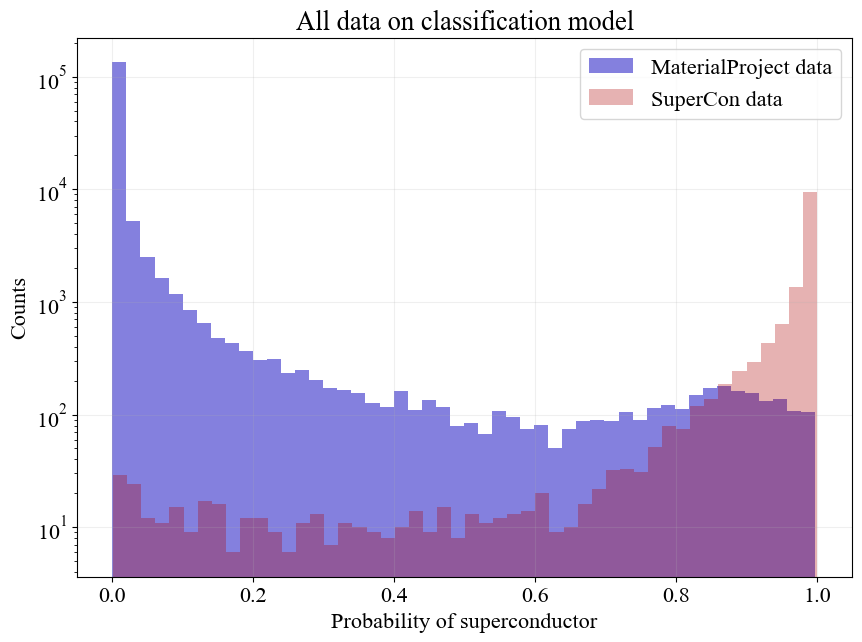

In [49]:
tot_pred = best_xgb_model.predict_proba(mp_clean[final_features])[:,0]
sc_pred = best_xgb_model.predict_proba(sc_features[final_features])[:,0]

plt.figure(figsize=(10,7))
plt.hist(1-tot_pred, alpha=0.5, bins=50, label='MaterialProject data')
plt.hist(1-sc_pred, alpha=0.3, bins=50, label='SuperCon data')

plt.yscale('log')
plt.xlabel('Probability of superconductor')
plt.ylabel('Counts')
plt.title('All data on classification model')
plt.legend()

plt.savefig('classification_hist.png')
np.savetxt('MP_non_SC_prob.txt', tot_pred)
mp_clean.to_csv('mp_clean.csv') #No SuperCon materials

chem_clean = chem_MP[~overlap]
df_chem_clean = pd.DataFrame(chem_clean)
df_chem_clean.to_csv('chem_mp_clean.csv')